# Ejercicio 5 - Analisis espacial de cianobacteria

Este cuaderno genera mapas por lago y fecha del indice de cianobacteria,
usando el contorno real de cada lago (no solo la caja de consulta), mapas
comparativos con la misma escala de color, un mapa interactivo y una
descripcion de zonas de concentracion.

Lee unicamente los raster ya exportados por el ejercicio 3
(`data/processed/manifest_indices.csv`); no descarga ni recalcula indices
aqui. La funcionalidad vive en `src/analisis_espacial.py`; este cuaderno
solo la orquesta y documenta los resultados.

## Decisiones documentadas antes de ver los resultados

- **Geometria real del lago**: se obtuvo una vez de OpenStreetMap (Overpass
  API, `natural=water`) y se cacheo en
  `data/raw/geojson/lago_<lago>_boundary.geojson`. Se **intersecta** con la
  mascara de agua SCL que ya uso el ejercicio 3 (no la reemplaza): un pixel
  cuenta como valido solo si paso la clasificacion SCL de esa escena Y cae
  dentro del contorno real del lago.
- **Escala de color fija**: percentil 98 de todos los pixeles validos de
  cianobacteria de ambos lagos, con un piso en el umbral de "valor alto"
  (`UMBRAL_CIANOBACTERIA_ALTO_UGL`, ver ejercicio 8.1). Es una decision de
  visualizacion, no cambia el umbral cuantitativo.
- **Fecha "critica" por lago**: se usa provisionalmente la fecha que el
  criterio de pico del ejercicio 4 (`analisis_temporal.flag_peaks`, media +
  1 desviacion estandar) ya marca como pico. Es una eleccion provisional;
  el ejercicio 7 puede confirmarla o ajustarla con el analisis conjunto de
  los dos lagos.
- **Fecha comun para comparar lagos**: `2026-04-13`, la unica fecha oficial
  compartida por ambos lagos.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raiz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display, IFrame

from src import analisis_espacial as ae
from src import analisis_temporal as at
from src.config import LAGOS, UMBRAL_CIANOBACTERIA_ALTO_UGL

print(f'Raiz del proyecto: {ROOT}')
print(f'Umbral de valor alto: {UMBRAL_CIANOBACTERIA_ALTO_UGL} ug/L (WHO Alert Level 1)')

Raiz del proyecto: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales
Umbral de valor alto: 10.0 ug/L (WHO Alert Level 1)


## 1. Contorno real de los lagos (OpenStreetMap)

`EJECUTAR_DESCARGA_CONTORNO = False` porque el contorno real de ambos
lagos ya se descargo y cacheo una vez
(`data/raw/geojson/lago_<lago>_boundary.geojson`); volver a pedirlo
lanzaria `FileExistsError` a proposito, para no sobrescribir el archivo
cacheado. Se muestra la comparacion de area contra el bbox de consulta
como chequeo de cordura: el contorno real debe ser bastante mas pequeno
que la caja rectangular.

In [2]:
EJECUTAR_DESCARGA_CONTORNO = False

if EJECUTAR_DESCARGA_CONTORNO:
    for lago in LAGOS:
        path = ae.request_lake_boundary(lago)
        print(f'{lago}: {path}')

comparaciones = pd.DataFrame([ae.compare_bbox_vs_boundary_area(lago) for lago in LAGOS])
display(comparaciones)

,lago,area_bbox_km2,area_boundary_km2,razon_boundary_bbox
0,atitlan,474.2274,124.7004,0.2630
1,amatitlan,121.7052,15.0243,0.1234


## 2. Consistencia de rejilla entre fechas

Los tres indices de una misma fecha ya se exportan alineados (ejercicio
3), pero cada fecha se calcula por separado: aqui se verifica que las 11
fechas de un mismo lago tambien compartan CRS, transform y dimensiones
entre si, requisito para apilar las fechas en el ejercicio 8.2.

In [3]:
for lago in LAGOS:
    resultado = ae.check_grid_consistency(lago)
    print(f"{lago}: consistente={resultado['consistente']} (referencia {resultado['fecha_referencia']})")
    for d in resultado['discrepancias']:
        print(f"    discrepancia en {d['fecha']}: {d['width']}x{d['height']}")

atitlan: consistente=True (referencia 2025-01-18)
amatitlan: consistente=True (referencia 2025-01-28)


## 3. Escala de color fija

Percentil 98 de todos los pixeles validos (SCL-agua ^ contorno real) de
cianobacteria de ambos lagos, con un piso en el umbral de "valor alto".
Esta misma escala (`vmin`, `vmax`) se usa en todos los mapas comparativos
de este cuaderno para que los colores sean comparables entre fechas y
entre lagos.

In [4]:
VMIN, VMAX = ae.comparison_scale()
print(f'Escala de color fija: [{VMIN:.2f}, {VMAX:.2f}] ug/L')

Escala de color fija: [0.00, 10.00] ug/L


## 4. Mapas individuales por fecha

Se genera un mapa PNG por cada una de las 22 combinaciones lago-fecha en
`results/maps/` (titulo, fecha, unidad, leyenda, escala de color fija y
nota de cobertura valida). Aqui solo se muestran en linea dos ejemplos
representativos por lago; los 22 productos completos quedan en el
repositorio para revision.

In [5]:
metadatos_mapas = []

for lago in LAGOS:
    rows = at.cianobacteria_rows()
    ready, _pending = at.split_ready_pending([r for r in rows if r['lago'] == lago])
    for row in ready:
        metadatos_mapas.append(ae.save_cyano_map_png(lago, row['fecha'], vmin=VMIN, vmax=VMAX))

print(f'{len(metadatos_mapas)} mapas individuales guardados en results/maps/')

22 mapas individuales guardados en results/maps/


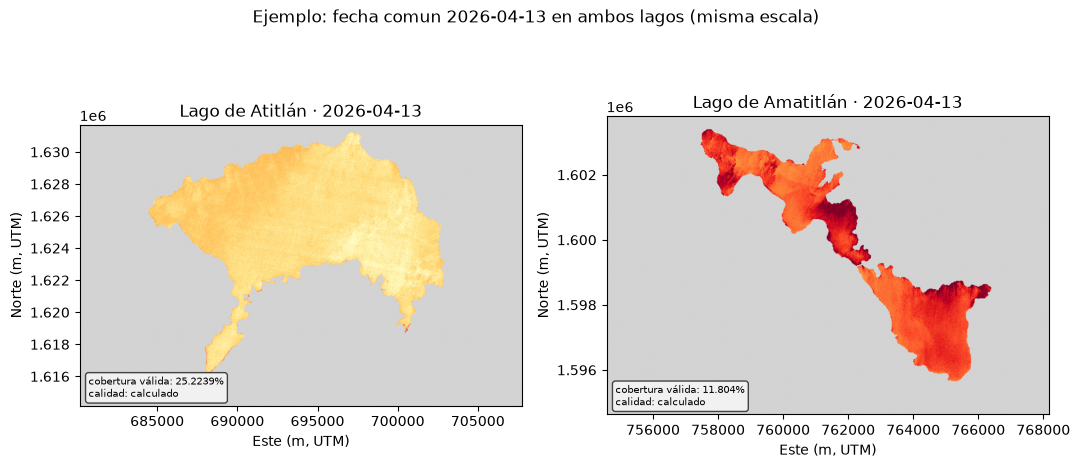

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ae.plot_cyano_map('atitlan', '2026-04-13', ax=axes[0], vmin=VMIN, vmax=VMAX)
ae.plot_cyano_map('amatitlan', '2026-04-13', ax=axes[1], vmin=VMIN, vmax=VMAX)
fig.suptitle('Ejemplo: fecha comun 2026-04-13 en ambos lagos (misma escala)')
plt.tight_layout()
plt.show()

## 5. Seleccion de fechas para los paneles comparativos

Por lago, se eligen: la fecha de menor promedio (referencia/valor bajo,
entre las de cobertura completa), la fecha "critica" provisional (pico
segun `flag_peaks`, ver decisiones arriba) y la fecha comun `2026-04-13`.

In [7]:
resumen = pd.DataFrame(at.flag_peaks(at.build_resumen_temporal()))
resumen['cyano_promedio'] = resumen['cyano_promedio'].astype(float)

fechas_por_lago = {}
for lago in LAGOS:
    serie = resumen[resumen['lago'] == lago]
    completas = serie[serie['quality_flag'] == 'calculado']
    fecha_baja = completas.sort_values('cyano_promedio').iloc[0]['fecha']
    picos = serie[serie['es_pico']]
    fecha_critica = picos.sort_values('cyano_promedio', ascending=False).iloc[0]['fecha'] if not picos.empty else None
    fechas = [f for f in (fecha_baja, fecha_critica, '2026-04-13') if f is not None]
    fechas = list(dict.fromkeys(fechas))  # sin duplicados, conserva orden
    fechas_por_lago[lago] = fechas
    print(f'{lago}: fecha baja={fecha_baja}, fecha critica (pico provisional)={fecha_critica}, fechas del panel={fechas}')

atitlan: fecha baja=2026-03-24, fecha critica (pico provisional)=2026-04-13, fechas del panel=['2026-03-24', '2026-04-13']
amatitlan: fecha baja=2026-02-02, fecha critica (pico provisional)=2026-06-19, fechas del panel=['2026-02-02', '2026-06-19', '2026-04-13']


## 6. Paneles comparativos con escala fija

Un panel por lago (misma escala de color, una sola barra de color) y un
panel adicional comparando ambos lagos en la fecha comun.

In [8]:
for lago in LAGOS:
    metadata = ae.save_cyano_comparison_png(lago, fechas_por_lago[lago], vmin=VMIN, vmax=VMAX)
    metadatos_mapas.append(metadata)
    print(f"{lago}: {metadata['archivo']}")

atitlan: results/maps/atitlan_comparativo_cianobacteria.png


amatitlan: results/maps/amatitlan_comparativo_cianobacteria.png


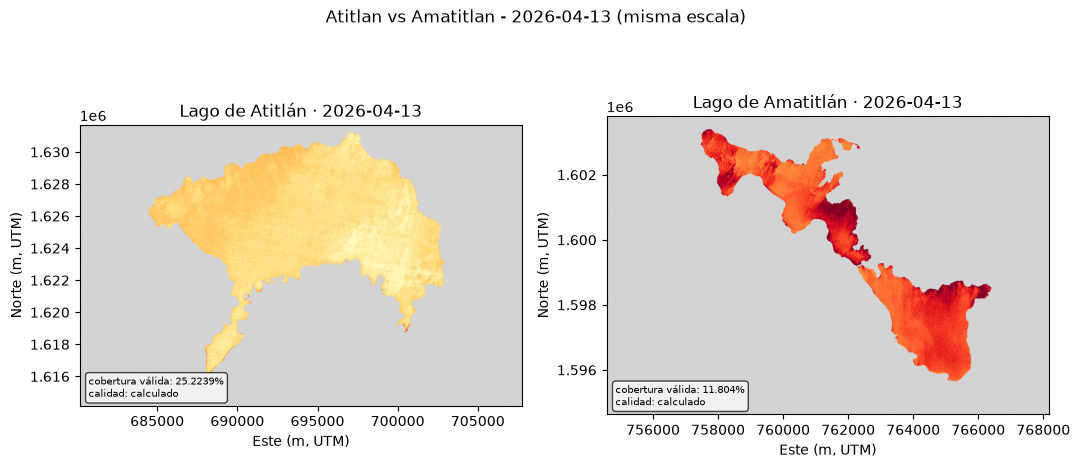

Guardado: C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\results\maps\comparacion_lagos_2026-04-13_cianobacteria.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
ae.plot_cyano_map('atitlan', '2026-04-13', ax=axes[0], vmin=VMIN, vmax=VMAX)
ae.plot_cyano_map('amatitlan', '2026-04-13', ax=axes[1], vmin=VMIN, vmax=VMAX)
out_path = ae.DIR_RESULTS_MAPS / 'comparacion_lagos_2026-04-13_cianobacteria.png'
fig.suptitle('Atitlan vs Amatitlan - 2026-04-13 (misma escala)')
plt.tight_layout()
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
metadatos_mapas.append({
    'lago': 'atitlan;amatitlan', 'fecha': '2026-04-13', 'indice': 'cianobacteria',
    'tipo_mapa': 'comparativo_entre_lagos', 'archivo': out_path.resolve().relative_to(ROOT.resolve()).as_posix(),
    'formato': 'png', 'vmin': VMIN, 'vmax': VMAX, 'umbral_alto_ugl': '',
    'generado_en': pd.Timestamp.now().isoformat(),
})
print(f'Guardado: {out_path}')

## 7. Mapa interactivo (Folium)

Un HTML por lago con una capa por fecha (alternable) y el contorno real
superpuesto. El mapa interactivo complementa las figuras estaticas de
arriba, no las sustituye.

In [10]:
for lago in LAGOS:
    rows = at.cianobacteria_rows()
    ready, _pending = at.split_ready_pending([r for r in rows if r['lago'] == lago])
    fechas = sorted(r['fecha'] for r in ready)
    metadata = ae.save_folium_map(lago, fechas, vmin=VMIN, vmax=VMAX)
    metadatos_mapas.append(metadata)
    print(f"{lago}: {metadata['archivo']}")

atitlan: results/maps/atitlan_interactivo.html


amatitlan: results/maps/amatitlan_interactivo.html


In [11]:
display(IFrame(src=str((ROOT / metadatos_mapas[-1]['archivo']).as_posix()), width=700, height=450))

## 8. Fechas con advertencia de calidad (artefactos vs. patrones reales)

Antes de describir zonas de concentracion, se listan las fechas que el
ejercicio 3 ya marco con `quality_flag` distinto de `calculado` (cobertura
parcial o fraccion alta de pixeles fuera de rango). Un cambio visible en
esas fechas puede ser un artefacto de nubosidad o de reflectancia, no
necesariamente un evento real; se interpretan por separado.

In [12]:
sospechosas = pd.DataFrame(ae.suspicious_dates())
display(sospechosas[['lago', 'fecha', 'quality_flag', 'cobertura_valida_pct']] if not sospechosas.empty else 'Sin fechas sospechosas')

,lago,fecha,quality_flag,cobertura_valida_pct
0,amatitlan,2026-02-07,cobertura_parcial_oficial,11.7192
1,atitlan,2025-01-18,revisar_valores_atipicos,25.5899
2,atitlan,2025-07-17,revisar_valores_atipicos,24.1457
3,atitlan,2025-11-21,revisar_valores_atipicos,25.3667
4,atitlan,2025-12-29,revisar_valores_atipicos,25.5996
5,atitlan,2026-02-12,revisar_valores_atipicos,25.3465
6,atitlan,2026-07-22,revisar_valores_atipicos,25.1764


## 9. Descripcion espacial de zonas de concentracion

Para dar una orientacion espacial legible (norte/sur), se divide la mascara
valida de cada lago en mitad norte y mitad sur (segun la fila de pixel) y
se compara el promedio de cianobacteria de cada mitad en la fecha critica
provisional de cada lago. Los pixeles invalidos (nube, fuera del lago) se
excluyen de ambos promedios; nunca se cuentan como "sin cianobacteria".

In [13]:
import numpy as np

resumen_zonas = []
for lago in LAGOS:
    fecha = fechas_por_lago[lago][1] if len(fechas_por_lago[lago]) > 1 else fechas_por_lago[lago][0]
    row = ae._cyano_row(lago, fecha)
    array, profile = ae.open_index_raster(row)
    valid = ae.combined_valid_mask(array, lago, profile)
    mitad = profile['height'] // 2
    norte_valid = valid[:mitad, :]
    sur_valid = valid[mitad:, :]
    prom_norte = float(np.nanmean(np.where(norte_valid, array[:mitad, :], np.nan)))
    prom_sur = float(np.nanmean(np.where(sur_valid, array[mitad:, :], np.nan)))
    resumen_zonas.append({
        'lago': lago, 'fecha': fecha,
        'promedio_mitad_norte': round(prom_norte, 3),
        'promedio_mitad_sur': round(prom_sur, 3),
        'pixeles_validos_norte': int(norte_valid.sum()),
        'pixeles_validos_sur': int(sur_valid.sum()),
    })

display(pd.DataFrame(resumen_zonas))

,lago,fecha,promedio_mitad_norte,promedio_mitad_sur,pixeles_validos_norte,pixeles_validos_sur
0,atitlan,2026-04-13,2.176,1.874,1021092,197158
1,amatitlan,2026-06-19,13.211,9.783,75492,69481


## 10. Guardar metadatos de todos los mapas generados

`results/tables/metadata_mapas.csv` registra lago, fecha, tipo de mapa,
ruta del archivo, formato y la escala de color usada para cada producto
generado en este cuaderno.

In [14]:
path = ae.write_map_metadata(metadatos_mapas)
print(f'{len(metadatos_mapas)} filas de metadatos escritas en {path}')

27 filas de metadatos escritas en C:\Users\anna2\Desktop\data-science-lab-4-datos-geoespaciales\results\tables\metadata_mapas.csv


## 11. Resultado del ejercicio

- Contorno real de ambos lagos obtenido de OpenStreetMap, cacheado en
  `data/raw/geojson/lago_<lago>_boundary.geojson`, intersectado con la
  mascara SCL-agua del ejercicio 3 (no la reemplaza).
- 22 mapas individuales, un panel comparativo por lago y un panel de
  comparacion entre lagos, todos con la misma escala de color fija,
  guardados en `results/maps/`.
- Un mapa interactivo (Folium) por lago con una capa por fecha.
- `results/tables/metadata_mapas.csv` documenta cada producto generado.
- La fecha "critica" usada en los paneles comparativos es provisional
  (picos de `flag_peaks`); el ejercicio 7 puede confirmarla o ajustarla.
- La comparacion norte/sur de la seccion 9 es descriptiva y depende de la
  fecha elegida; no sustituye el analisis de persistencia del ejercicio
  8.2, que resume las 11 fechas por pixel.